In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import scanpy as sc
import os
from dotenv import load_dotenv; load_dotenv()
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad

from utils import preprocessing


BASE_PATH = os.getenv("BASE_PATH_FOR_SAVING")

FINAL_ADATA_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_+_NucSeq.h5ad"


In [2]:
NUCSEQ_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad"
SLIDETAGS_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata_zoned_ct-cured_aligned.h5ad"

nucseq = sc.read_h5ad(NUCSEQ_PATH)
slidetags = sc.read_h5ad(SLIDETAGS_PATH)

nucseq
slidetags

AnnData object with n_obs × n_vars = 537658 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.1_all_c

In [ ]:
def normalize_donor_id(d):
    import re
    if d == 'unassigned':
        return d
    if d.startswith("PCMC"):
        return d
    if d == "SCF-23-070-":
        return "SCF-23-070"
    d = re.sub(r'(CM2|CM6|CCF|MMC|CM|CF)$', '', d)  # strip suffixes
    d = re.sub(r'^PCMC', 'SCF', d)                    # fix prefix
    d = re.sub(r'[-_]+', '-', d)                       # normalize separators
    return d

# make donors have same fomat (just on nucseq)
nucseq.obs['donor_id'] = nucseq.obs['donor_id'].map(normalize_donor_id)

# fill missing sample in sludetags
slidetags.obs['donor_id'] = slidetags.obs['donor_id'].fillna("SCF-18-006")

# make nucseq have same cols name of slidetags
nucseq.obs.drop(columns=["library"], inplace=True)
nucseq.obs.rename(columns={"rna_index": "library"}, inplace=True)
nucseq.obs.rename(columns={"frac_intronic": "pct_intronic"}, inplace=True)
nucseq.obs['Sorted'] = "Unsorted"
nucseq.obs['x'] = np.nan
nucseq.obs['y'] = np.nan
nucseq.obs['has_spatial'] = False
nucseq.obs['library_id'] = nucseq.obs['bcl'].astype(str) + "_" + nucseq.obs['library'].astype(str)

# remmve bad samples
nucseq = nucseq[nucseq.obs["donor_id"]!="unassigned"].copy()

# print dornos not present in both
print(sorted(set(nucseq.obs.donor_id.unique())))
print(set(slidetags.obs.donor_id.unique()))
print("Slidetags samples not in Nucseq")
print(list(set(slidetags.obs.donor_id.unique()).difference(set(nucseq.obs.donor_id.unique()))))

['PCMC-16-011', 'PCMC-16-012', 'SCF-18-003', 'SCF-18-004', 'SCF-18-006', 'SCF-19-009', 'SCF-19-014', 'SCF-19-018', 'SCF-19-020', 'SCF-20-023', 'SCF-20-024', 'SCF-20-025', 'SCF-20-026', 'SCF-21-027', 'SCF-21-029', 'SCF-21-030', 'SCF-21-032', 'SCF-21-034', 'SCF-21-037', 'SCF-21-038', 'SCF-21-041', 'SCF-22-042', 'SCF-22-043', 'SCF-22-044', 'SCF-22-045', 'SCF-22-046', 'SCF-22-048', 'SCF-22-049', 'SCF-22-050', 'SCF-22-052', 'SCF-22-054', 'SCF-22-056', 'SCF-22-057', 'SCF-22-058', 'SCF-22-060', 'SCF-22-063', 'SCF-22-065', 'SCF-22-067', 'SCF-23-068', 'SCF-23-070-', 'SCF-23-072', 'SCF-23-074', 'SCF-23-075', 'SCF-23-079', 'SCF-23-080', 'SCF-23-081', 'SCF-23-083']
{'SCF-20-025', 'SCF-22-057', 'SCF-18-006', 'SCF-18-003', 'SCF-20-026', 'SCF-19-014', 'SCF-23-068', 'SCF-22-043', 'SCF-20-024'}
Slidetags samples not in Nucseq
[]


In [4]:
display(nucseq)
display(slidetags)

nucseq.obs["dataset"] = "nucseq"
slidetags.obs["dataset"] = "slidetags"

nucseq.obs = nucseq.obs[[
    'x', 'y', 'has_spatial',
    'pct_intronic',
    'Neighborhood_name', 'Class_name', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 
    'donor_id', 
    'bcl', 'library', 'library_id','Sorted', 
    'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 
    'ct_for_deg', 'is_neuron',
    #  ...     #... # ATTNETION: Missing columns will be added after when we merge
    'dataset'
]].copy()

slidetags.obs = slidetags.obs[[
    'x', 'y', 'has_spatial',
    'pct_intronic',
    'Neighborhood_name', 'Class_name', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability',
    'sample', 'donor_id', #'condition', 'sex', 'age_at_onset', 'age_at_death', --> let stake from oher datset
    'bcl', 'library', 'library_id','Sorted', 
    'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 
    'ct_for_deg', 'is_Mito_cluster_matrix', 'is_mito_cluster_patch', 'is_neuron',
    'puck', 'region', 'radial_high_mito_patch', 'radial_patch_in_death', 'radial_patch_in_healthy', 'mito_radial_neighborhood', 
    'dataset'

]].copy()


AnnData object with n_obs × n_vars = 231077 × 38601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'pct_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'brain_bank', 'cohort', 'condition', 'sex', 'age_of_onset', 'age_of_

AnnData object with n_obs × n_vars = 537658 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.1_all_c

In [5]:
# take oly gene interesection

# check genes
genes_in_nucseq = set(nucseq.var_names)
genes_in_slidetags = set(slidetags.var_names)
genes_in_both = genes_in_nucseq.intersection(genes_in_slidetags)
print(f"Genes in NucSeq: {len(genes_in_nucseq)}")
print(f"Genes in SlideTags: {len(genes_in_slidetags)}")
print(f"Genes in both: {len(genes_in_both)}")

mask = nucseq.var_names.isin(genes_in_both)
nucseq = nucseq[:, mask]
print(f"Genes in merged data: {len(set(nucseq.var_names))}")

mask = slidetags.var_names.isin(genes_in_both)
slidetags = slidetags[:, mask]
print(f"Genes in merged data: {len(set(slidetags.var_names))}")

Genes in NucSeq: 38601
Genes in SlideTags: 37464
Genes in both: 35576
Genes in merged data: 35576
Genes in merged data: 35576


In [6]:
# del nucseq.layers["counts"]
# del slidetags.layers["counts"]
# del nucseq.layers["log1p_norm"]
# del slidetags.layers["log1p_norm"]

In [7]:
import gc
import anndata.experimental

TMP_NUCSEQ = "/tmp/nucseq_clean.h5ad"
TMP_SLIDETAGS = "/tmp/slidetags_clean.h5ad"

# --- write nucseq ---
for key in list(nucseq.obsm.keys()):
    if key not in ('spatial', 'spatial_raw'):
        del nucseq.obsm[key]
nucseq.obsp = {}; nucseq.uns = {}
# need to add obsm so they eill nto eb dorpped
nucseq.obsm['spatial_raw'] = np.full((nucseq.n_obs, 2), np.nan) 
nucseq.obsm['spatial'] = np.full((nucseq.n_obs, 2), np.nan)
nucseq.write_h5ad(TMP_NUCSEQ)

# --- write slidetags ---
for key in list(slidetags.obsm.keys()):
    if key not in ('spatial', 'spatial_raw'):
        del slidetags.obsm[key]
slidetags.write_h5ad(TMP_SLIDETAGS)

# --- merge on disk, never loads both into RAM ---
anndata.experimental.concat_on_disk(
    [TMP_NUCSEQ, TMP_SLIDETAGS],
    out_file=FINAL_ADATA_PATH,
    join="outer",          # genes already filtered to intersection
    #merge="same",
)


/tmp/ipykernel_441061/3403563233.py:10: ImplicitModificationWarning: Removing element `.obsm['X_pca']` of view, initializing view as actual.
  del nucseq.obsm[key]
/tmp/ipykernel_441061/3403563233.py:20: ImplicitModificationWarning: Removing element `.obsm['X_pca']` of view, initializing view as actual.
  del slidetags.obsm[key]


In [8]:
stop

NameError: name 'stop' is not defined

In [ ]:
# adata_merged = ad.concat(
#     [nucseq, slidetags],
#     join='outer',    # ON GENES and OBS   
      
# )

# # verufy both cells and genes are unique
# assert adata_merged.obs_names.is_unique, "Obs names are not unique after merge!"
# assert adata_merged.var_names.is_unique, "Var names are not unique after merge!"

# adata_merged

In [3]:
adata_merged = sc.read_h5ad(FINAL_ADATA_PATH)
adata_merged

AnnData object with n_obs × n_vars = 768735 × 35576
    obs: 'x', 'y', 'has_spatial', 'pct_intronic', 'Neighborhood_name', 'Class_name', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'donor_id', 'bcl', 'library', 'library_id', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'ct_for_deg', 'is_neuron', 'dataset', 'sample', 'is_Mito_cluster_matrix', 'is_mito_cluster_patch', 'puck', 'region', 'radial_high_mito_patch', 'radial_patch_in_death', 'radial_patch_in_healthy', 'mito_radial_neighborhood'
    obsm: 'spatial', 'spatial_raw'
    layers: 'counts', 'log1p_norm'

In [4]:
adata_merged.obs["donor_id"].value_counts()

# leave all toehr as they are, just fix this one sample that has a typo in donor id, so it will be merged with the rest of the samples from same donor
adata_merged.obs["donor_id"] = adata_merged.obs["donor_id"].map({"SCF-23-070-": "SCF-23-070"}).fillna(adata_merged.obs["donor_id"])

adata_merged.obs["donor_id"].value_counts()


donor_id
SCF-18-006     136479
SCF-22-043     102727
SCF-18-003     102631
SCF-20-025      54563
SCF-19-014      43339
SCF-20-024      41526
SCF-20-026      41369
SCF-23-068      39616
SCF-22-057      31339
SCF-19-020       8225
SCF-21-037       8019
SCF-22-045       7925
SCF-22-050       7147
SCF-22-049       6852
SCF-22-042       6163
SCF-23-072       6110
SCF-21-038       6058
SCF-22-063       5971
SCF-21-027       5925
SCF-21-041       5674
SCF-20-023       5637
SCF-22-067       5134
SCF-21-032       5062
SCF-22-046       5034
SCF-23-079       4983
SCF-22-054       4903
SCF-23-070       4791
SCF-22-065       4678
SCF-23-075       4542
SCF-23-074       4383
SCF-18-004       4302
SCF-21-030       4236
SCF-19-009       4063
SCF-22-044       4062
SCF-22-056       3872
SCF-22-058       3801
SCF-22-052       3657
SCF-22-048       3257
SCF-23-080       3128
SCF-21-034       2980
SCF-21-029       2825
PCMC-16-011      2490
SCF-19-018       2484
PCMC-16-012      2187
SCF-23-083       1616
S

In [5]:
# check genes
print(f"Genes in merged data: {len(set(adata_merged.var_names))}")

Genes in merged data: 35576


In [6]:
# add metadata
df = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/XDP dataset metadata - Gabri's Version.csv")
#df['donor_id'] = df['donor_id'].map(normalize_donor_id)
df.rename(columns={'condition': 'condition_from_metadata'}, inplace=True)
df.drop(columns=['from_where_this_info_comes_from'], inplace=True)
df.columns = df.columns.str.lower()

display(df)

adata_merged.obs = adata_merged.obs.merge(df, on='donor_id', how='left')

,donor_id,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,year_collected,repeat_length,repeat_length_notes,age_of_onset,age_of_death,disease_duration,cap,immediate_cause_of_death
0,SCF-22-054,SCF-22-054CM,M,Control,C_1,6.88,0.79,5.0,A,6.0,SCF,2022,0,NaN,not_applicable,51,not_applicable,0.0,Acute Myocardial Infarction
1,SCF-23-075,SCF_23_075CM,M,Control,C_2,6.84,0.80,5.0,A,NaN,SCF,2023,0,NaN,not_applicable,60,not_applicable,0.0,Uremia
2,SCF-22-067,SCF_22_067CM,M,Control,C_2,6.08,0.73,5.0,A,NaN,SCF,2023,0,NaN,not_applicable,19,not_applicable,0.0,Stab wound
3,SCF-23-079,SCF_23_079CF,F,Control,C_2,5.61,0.74,5.0,A,NaN,SCF,2023,0,NaN,not_applicable,47,not_applicable,0.0,Colon Carcinoma
4,SCF-22-065,SCF_22_065CM,M,Control,C_2,5.35,0.71,5.0,A,NaN,SCF,2022,0,NaN,not_applicable,69,not_applicable,0.0,Heart Failure
5,SCF-23-072,SCF_23_072CF,F,Control,C_2,5.11,0.72,5.0,A,NaN,SCF,2023,0,NaN,not_applicable,28,not_applicable,0.0,Sepsis
6,SCF-22-050,SCF_22-050CM6,M,Control,C_3,6.39,0.74,4.0,B,6.2,SCF,2022,0,NaN,not_applicable,78,not_applicable,0.0,NaN
7,SCF-23-068,SCF-23-068CM,M,Control,C_1,6.30,0.76,4.0,B,6.0,SCF,2023,0,NaN,not_applicable,43,not_applicable,0.0,Myocardial Infraction
8,SCF-23-074,SCF_23_074CF,F,Control,C_2,4.42,0.66,4.0,B,NaN,SCF,2023,0,NaN,not_applicable,26,not_applicable,0.0,Uremia
9,SCF-22-057,SCF_22-057CM,M,Control,C_3,6.76,0.80,3.5,BC,NaN,SCF,2022,0,NaN,not_applicable,66,not_applicable,0.0,Community Aquire Pnuemonia High Risk


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [10]:
# creat image

# Create the condition
condition = adata_merged.obs['puck'].notna()

# Create the concatenated string
combined_string = adata_merged.obs['donor_id'].astype(str) + adata_merged.obs['puck'].astype(str)

# Apply the logic
adata_merged.obs['image'] = np.where(condition, combined_string, np.nan)

# Verify

### Metadata

In [7]:
# distubuto of cells of samples presne tin btih datasets
slidetags_samples = set(adata_merged.obs[adata_merged.obs['dataset'] == 'slidetags']['donor_id'].unique())
for sample in adata_merged.obs['donor_id'].unique():
    if not (sample in slidetags_samples):
        continue

    print(f"Sample {sample}:")
    display(adata_merged.obs[adata_merged.obs['donor_id'] == sample]['dataset'].value_counts())
    display((adata_merged.obs[adata_merged.obs['donor_id'] == sample]['has_spatial'] == True).sum())

Sample SCF-20-025:


dataset
slidetags    41852
nucseq       12711
Name: count, dtype: int64

np.int64(25914)

Sample SCF-18-006:


dataset
slidetags    131788
nucseq         4691
Name: count, dtype: int64

...

dataset
slidetags    36870
nucseq        4499
Name: count, dtype: int64

np.int64(27048)

Sample SCF-22-057:


dataset
slidetags    27228
nucseq        4111
Name: count, dtype: int64

np.int64(21735)

In [8]:
# meatda IMPORTANT cols that have nan
for col in [
        "donor_id", "dataset", 
        'brain_bank', 'cohort', 'condition', 'sex', 'age_of_onset', 'age_of_death', 
        'repeat_length', 'year_collected', 'disease_duration', 'rqs', 'dv200', 'ph', 'mqs_numerical', 
        'mqs', 'immediate_cause_of_death'
    ]:
    
    n_missing = adata_merged.obs[col].isna().sum()
    if n_missing > 0:
        print(f"{col}: {n_missing} missing values")
        display(adata_merged.obs[adata_merged.obs[col].isna()][['dataset', 'donor_id', 'age_of_death', 'condition']].drop_duplicates())

age_of_onset: 23197 missing values


,dataset,donor_id,age_of_death,condition
12721,nucseq,SCF-21-038,43,XDP
21847,nucseq,SCF-22-048,46,XDP
21868,nucseq,SCF-22-044,50,XDP
21886,nucseq,SCF-22-042,50,XDP
21896,nucseq,SCF-22-052,43,XDP


disease_duration: 23197 missing values


,dataset,donor_id,age_of_death,condition
12721,nucseq,SCF-21-038,43,XDP
21847,nucseq,SCF-22-048,46,XDP
21868,nucseq,SCF-22-044,50,XDP
21886,nucseq,SCF-22-042,50,XDP
21896,nucseq,SCF-22-052,43,XDP


ph: 303997 missing values


,dataset,donor_id,age_of_death,condition
7,nucseq,SCF-20-024,46,XDP
10,nucseq,SCF-22-043,52,XDP
12719,nucseq,SCF-23-070,46,XDP
12722,nucseq,SCF-21-029,52,XDP
12723,nucseq,SCF-21-032,66,XDP
12727,nucseq,SCF-22-049,88,Control
12732,nucseq,SCF-22-063,56,Control
12733,nucseq,SCF-23-074,26,Control
12790,nucseq,SCF-21-034,55,XDP
12800,nucseq,SCF-22-067,19,Control


immediate_cause_of_death: 19235 missing values


,dataset,donor_id,age_of_death,condition
12720,nucseq,SCF-21-027,56,XDP
21846,nucseq,SCF-22-050,78,Control
21886,nucseq,SCF-22-042,50,XDP


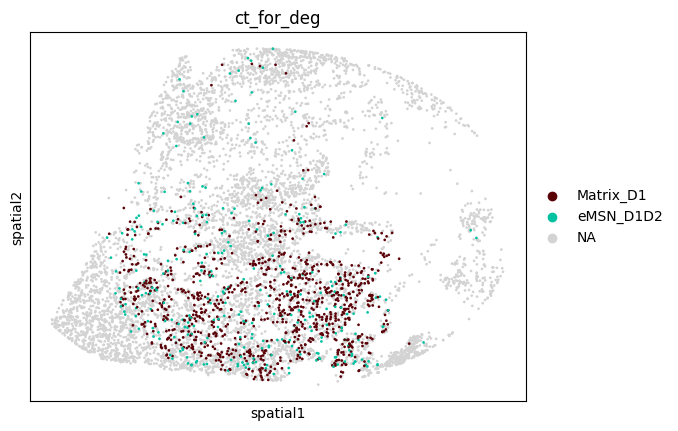

In [11]:
# spatial
a = adata_merged[adata_merged.obs['image'] == "SCF-20-025puck1"].copy()
sc.pl.embedding(a, basis='spatial', color='ct_for_deg', groups=["Matrix_D1", "eMSN_D1D2"])

# Save

In [12]:
adata_merged.write_h5ad(FINAL_ADATA_PATH)

In [ ]:
STOP

In [ ]:
adata_merged = sc.read_h5ad(FINAL_ADATA_PATH)

# Umap

In [16]:

SEED = 42
batch_key="batch_key"

adata_merged.obs[batch_key] = adata_merged.obs["donor_id"].astype(str) + "_" + adata_merged.obs["dataset"].astype(str)
# HVG — fall back to no batch_key if some batch is too small
print("Running HVG...")
try:
    sc.pp.highly_variable_genes(adata_merged, n_top_genes=3000, flavor="seurat_v3",
                                layer="counts", batch_key=batch_key)
except ValueError as e:
    print(f"WARNING: HVG with batch_key failed ({e}), retrying without batch_key")
    sc.pp.highly_variable_genes(adata_merged, n_top_genes=3000, flavor="seurat_v3",
                                layer="counts", batch_key=None)

# Scale + PCA in place — PCA only uses HVGs via mask_var, so no copy needed
print("Scaling + PCA...")
sc.pp.scale(adata_merged, max_value=10)
sc.tl.pca(adata_merged, svd_solver="randomized", n_comps=50, random_state=SEED,
            mask_var="highly_variable")
adata_merged.X = adata_merged.layers["counts"].copy()   # undo scaling on X

# Optional Harmony, then neighbors on whichever rep we end up with
import harmonypy
if batch_key is None:
    raise ValueError("batch_key must be provided for Harmony integration.")
print("Running Harmony batch correction...")
ho = harmonypy.run_harmony(adata_merged.obsm["X_pca"], adata_merged.obs, vars_use=batch_key, max_iter_harmony=30)
Z = ho.Z_corr
print(f"Z_corr shape: {ho.Z_corr.shape}, n_obs: {adata_merged.n_obs}")
adata_merged.obsm["X_pca_harmony"] = Z.T if Z.shape[0] != adata_merged.n_obs else Z
rep = "X_pca_harmony"


print(f"Computing neighbors on {rep}...")
sc.pp.neighbors(adata_merged, use_rep=rep, n_pcs=30, random_state=SEED)

sc.tl.umap(adata_merged, random_state=SEED)

Running HVG...
Scaling + PCA...


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


: 

In [ ]:
adata_nn = adata_merged[adata_merged.obs["ct_for_deg"].isin(["Matrix_D1", "Matrix_D2", "Patch_D1", "Patch_D2"])].copy()

# ---